# Tuned CatBoost Model
## T1-T2

In [ ]:
import sys, os
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor
from skrub import TableReport
import joblib, os
import preprocess
import explore
import model
import model_catboost
from sklearn.preprocessing import PowerTransformer


os.environ['PYTHONWARNINGS'] = 'ignore'
MODEL_DIR = os.path.abspath('../models')


In [2]:
# Running through preprocessing steps
# Load raw data
df_im, df_cl = explore.load_data()

# Clean datasets
_im_id_cols = ['Patient', 'Timepoint', 'Date']
df_im_vis   = preprocess.clean_im(df_im, False)
df_cl_vis   = preprocess.clean_cl(df_cl, False)

# Immunological: drop >25% NaN columns, remove confirmed outliers
df_im_mod    = preprocess.remove_nan_cols(df_im_vis, verbose=False)
df_im_mod    = preprocess.remove_outlier_observations(df_im_mod, verbose=False)
df_im_mod    = preprocess.remove_for_modeling(df_im_mod, verbose=False)

# Clinical: drop >25% NaN columns
df_cl_mod    = preprocess.remove_nan_cols(df_cl_vis, verbose=False)
df_cl_mod    = preprocess.remove_for_modeling(df_cl_mod, verbose=False)

print(f"df_im_mod : {df_im_mod.shape}")
print(f"df_cl_mod : {df_cl_mod.shape}")


df_im_mod : (814, 77)
df_cl_mod : (842, 26)


In [3]:
# Constructing targets:
print('\nConstructing regression targets from clinical data')
pain_targets       = model.construct_datasets_targets(df_cl_mod, 'pain_scale',      [1, 2])
targets_under_load = model.construct_datasets_targets(df_cl_mod, 'pain_under_load', [1, 2])


Constructing regression targets from clinical data

  Target distributions:
    pain_reduction                              mean=1.347  std=2.051  [-4.000, 7.100]
    pain_reduction_pct                          mean=19.196  std=32.847  [-100.000, 87.654]

  Target distributions:
    pain_under_load_reduction                   mean=0.551  std=0.753  [-1.000, 3.000]
    pain_under_load_reduction_pct               mean=14.125  std=20.231  [-50.000, 75.000]


## Dataset Overview

In [4]:
print('\nConstructing datasets for modeling:')
# Construct model datasets for each target type:
_unique_targets = {
    'pain_reduction':            pain_targets,
    'pain_under_load_reduction': targets_under_load,
}

model_datasets = {}
for tgt, tdf in _unique_targets.items():
    model_datasets[tgt] = model.create_model_datasets(
        df_cl_mod, df_im_mod, tdf, timepoints=[1, 2]
    )
model_datasets['pain_reduction_pct'] = model_datasets['pain_reduction']



Constructing datasets for modeling:

Total Number of Clinical features: 24
  Dropping 7 Columns before modeling: ['morning_stiffness', 'pain_at_rest', 'pain_daytime', 'pain_night', 'pain_scale', 'pain_under_load', 'response']
  Dropped baseline target cols : ['pain_scale_t1']

Modeling datasets ready: (T1–T2 immunological data + clinical baseline variables:
Shape of Combined Dataset: (116, 95), Number of Patients: 116

Total Number of Clinical features: 24
  Dropping 7 Columns before modeling: ['morning_stiffness', 'pain_at_rest', 'pain_daytime', 'pain_night', 'pain_scale', 'pain_under_load', 'response']
  Dropped baseline target cols : ['pain_under_load_t1']

Modeling datasets ready: (T1–T2 immunological data + clinical baseline variables:
Shape of Combined Dataset: (115, 95), Number of Patients: 115


## Target: pain_reduction 

In [ ]:
_pt = PowerTransformer(method='yeo-johnson', standardize=True)
features= joblib.load(os.path.join(MODEL_DIR, 'top_features_list.pkl'))

cb_red_results, cb_red_model, cb_red_X, cb_red_ypred, cb_red_model_params, cb_patient_err = model_catboost.run_tuned_catboost(
        model_datasets['pain_reduction'],
        feature_list=features,
        target_col='pain_reduction',
        random_state=42,
        target_transformer=_pt)

# Save model and feature matrix
cb_red_model.save_model(os.path.join(MODEL_DIR, 'cb_red_model.cbm'))
joblib.dump(cb_red_X, os.path.join(MODEL_DIR, 'cb_red_X.pkl'))
joblib.dump(cb_patient_err, os.path.join(MODEL_DIR, 'cb_patient_err.pkl'))
print(' Saved model to cb_red_model.cbm and cb_red_X.pkl')



  CatBoost + Optuna + MRMR — pain_reduction
  n=116, p=92, K=15
  Outer 4×5=20 | Inner 4×5=20 | Model trials=50

─────────────────────────────────────────────────────────────────
  Outer fold 1/20
─────────────────────────────────────────────────────────────────
  MRMR Selected: 15/92 features — ['CD123lo Bas_t2_minus_t1', 'T8lo_t2_minus_t1', 'NK4_t2_minus_t1', 'mDC-1_t2_minus_t1', 'NKT_56+/16+_t2_minus_t1', 'T_CD25+_t2_minus_t1', 'TH_CD25hi_t2_minus_t1', 'Mo_HLADRhi_t2_minus_t1']...
    Trial   1/50: RMSE=1.0052  {'depth': 5, 'learning_rate': 0.23705688269828706, 'l2_leaf_reg': 1.3227908237200787, 'bagging_temperature': 0.31181848267981704}
    Trial   2/50: RMSE=0.9757  {'depth': 8, 'learning_rate': 0.004237260412327668, 'l2_leaf_reg': 1.4941744192199742, 'bagging_temperature': 0.7069343163430255}
    Trial   3/50: RMSE=0.9963  {'depth': 5, 'learning_rate': 0.22379901358345242, 'l2_leaf_reg': 6.843001068876014, 'bagging_temperature': 0.683434887910986}
    Trial   4/50: RMSE=0.9788 

[W 2026-03-19 02:35:42,315] Trial 31 failed with parameters: {'depth': 6, 'learning_rate': 0.007378813252362511, 'l2_leaf_reg': 5.9073372428090885, 'bagging_temperature': 0.8705565266131519} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\mufa\.conda\envs\mt26\lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "p:\UK_Erlangen\Student_folders\Muna Ahmed Farah - IMMO-LDRT01\master-thesis\notebooks\../src\model_catboost_mrmr.py", line 172, in model_objective
    rmses = joblib.Parallel(n_jobs=-1, prefer='threads')(
  File "c:\Users\mufa\.conda\envs\mt26\lib\site-packages\joblib\parallel.py", line 2072, in __call__
    return output if self.return_generator else list(output)
  File "c:\Users\mufa\.conda\envs\mt26\lib\site-packages\joblib\parallel.py", line 1682, in _get_outputs
    yield from self._retrieve()
  File "c:\Users\mufa\.conda\envs\mt26\lib\site-packages\joblib\pa

KeyboardInterrupt: 

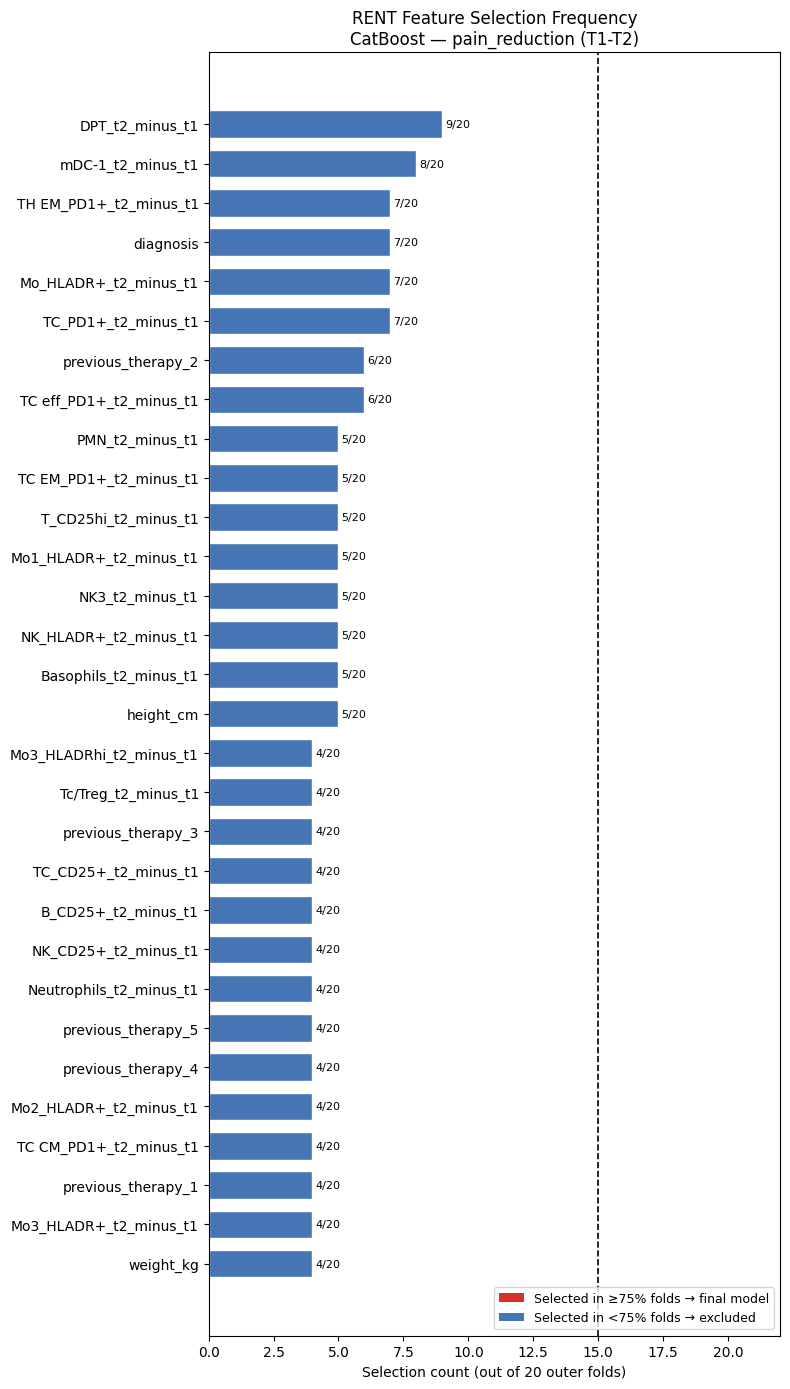


 SHAP — CatBoost (pain_reduction, T1-T2)

=== SHAP Analysis: CatBoost — pain_reduction (T1-T2) ===


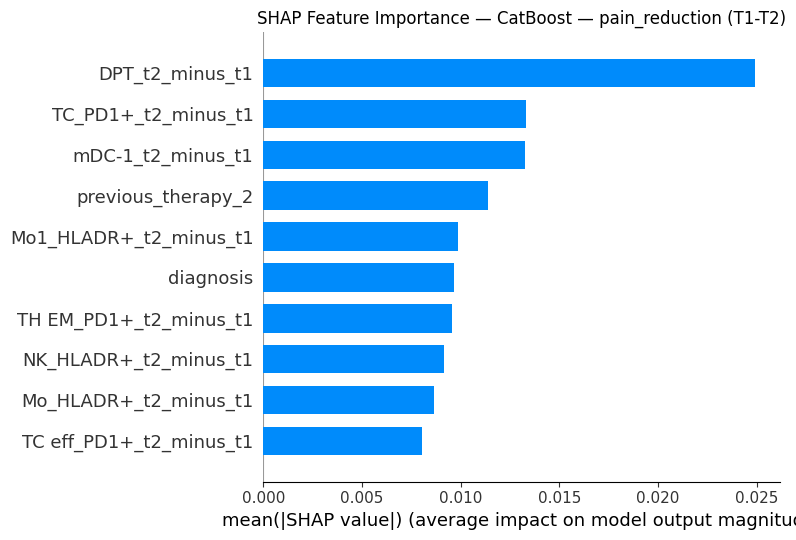

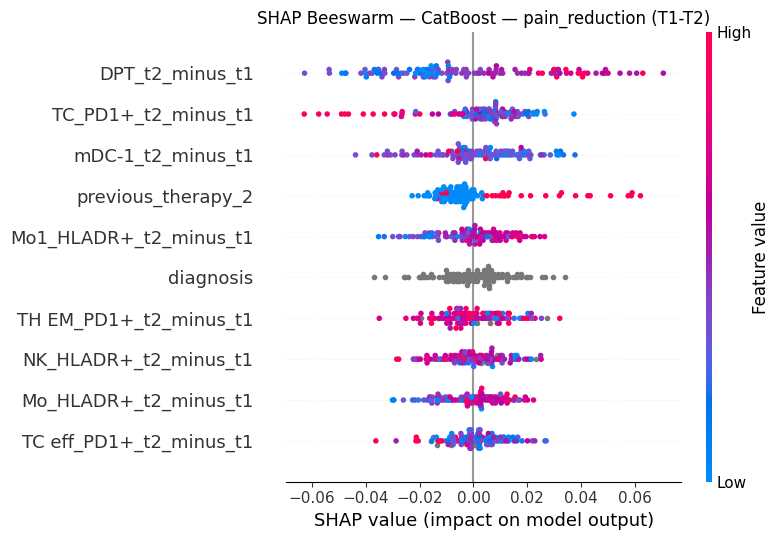

In [ ]:
# Plot Shap values
cb_red_model = CatBoostRegressor()
cb_red_model.load_model(os.path.join(MODEL_DIR, 'cb_red_model.cbm'))
cb_red_X = joblib.load(os.path.join(MODEL_DIR, 'cb_red_X.pkl'))

print('\n SHAP — CatBoost (pain_reduction, T1-T2)')
cb_red_shap = model.plot_shap_catboost(
    cb_red_model, cb_red_X)


## Target: pain_reduction_pct

In [12]:
print('\n1.2: CatBoost (Nested CV + RENT + Optuna) — pain_reduction_pct (T1-T2)')
_pt = PowerTransformer(method='yeo-johnson', standardize=True)

cb_pct_results, cb_pct_model, cb_pct_X, cb_pct_ypred, \
cb_pct_model_params, cb_pct_freq = \
    model_catboost.run_advanced_catboost_rent(
        model_datasets['pain_reduction_pct'],
        target_col='pain_reduction_pct',
        target_transformer=_pt,
    )

# Save model and feature matrix so SHAP can be run later without retraining —
cb_pct_model.save_model(os.path.join(MODEL_DIR, 'cb_pct_model.cbm'))
joblib.dump(cb_pct_X, os.path.join(MODEL_DIR, 'cb_pct_X.pkl'))
joblib.dump(cb_pct_freq, os.path.join(MODEL_DIR, 'cb_pct_freq.pkl'))
print(' Saved model to cb_pct_model.cbm and cb_pct_X.pkl')


1.2: CatBoost (Nested CV + RENT + Optuna) — pain_reduction_pct (T1-T2)

  CatBoost + Optuna + RENT — pain_reduction_pct
  n=117, p=91, τ₃=0.95
  Outer 4×5=20 | Inner 4×5=20 | RENT & Optuna trials=20 | K=100

─────────────────────────────────────────────────────────────────
  Outer fold 1/20
─────────────────────────────────────────────────────────────────
  Best RENT RMSE: 0.9869 Best Parameters: {'C': 1.2330416234654664, 'l1_ratio': 0.1420456273678036, 'tau_1': 0.7479176522860225, 'tau_2': 0.9353882346481023}
  RENT Selected: 91/91 features — ['PMN_t2_minus_t1', 'Neutrophils_t2_minus_t1', 'Eosinophils_t2_minus_t1', 'Basophils_t2_minus_t1', 'CD123lo Bas_t2_minus_t1', 'Monocytes_t2_minus_t1', 'T cells_t2_minus_t1', 'TH_t2_minus_t1']...
    Trial   1/20: RMSE=1.0031  {'depth': 10, 'learning_rate': 0.0575889323094765, 'l2_leaf_reg': 1.229981986421865, 'bagging_temperature': 0.35772697537576714}
    Trial   2/20: RMSE=0.9978  {'depth': 3, 'learning_rate': 0.0013893975468350828, 'l2_leaf_r

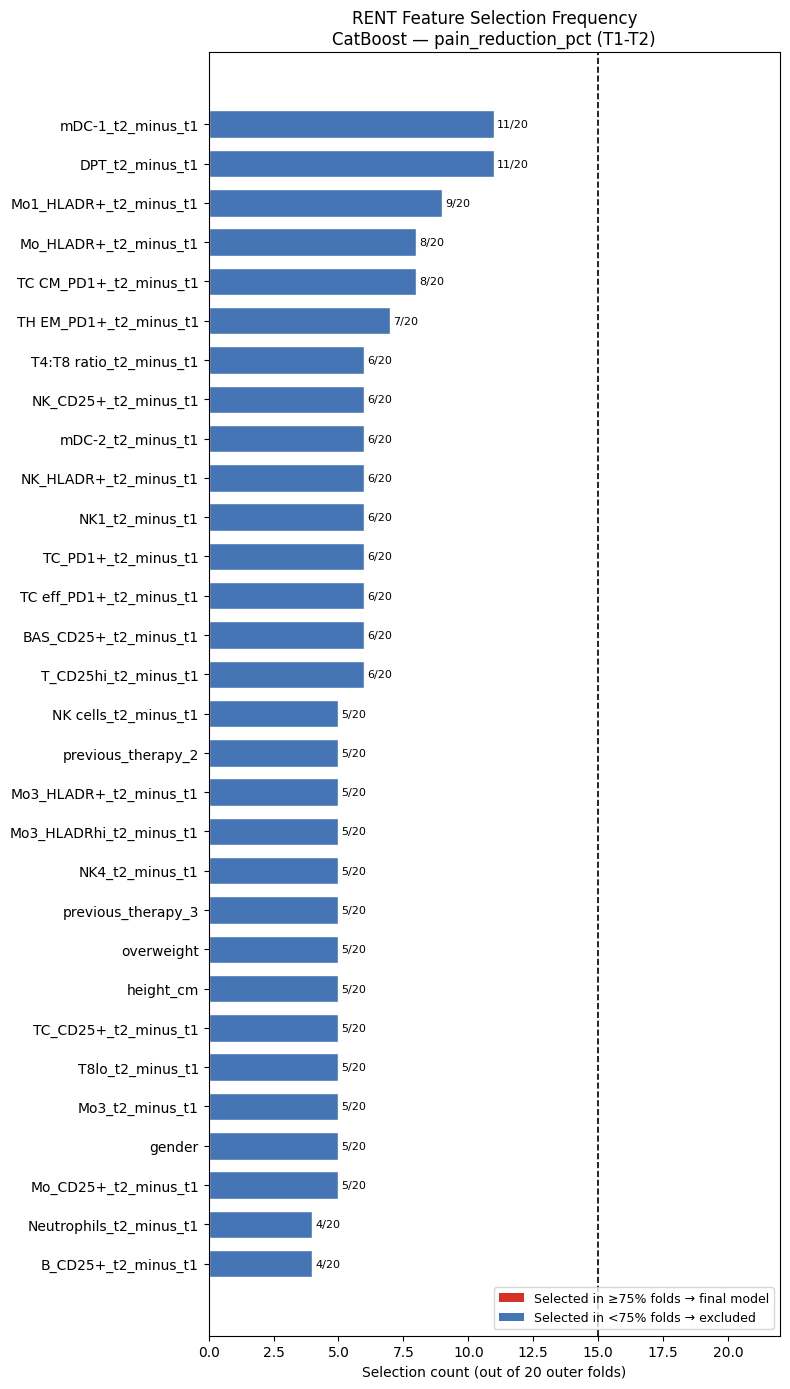


SHAP — CatBoost (pain_reduction_pct, T1-T2)

=== SHAP Analysis: CatBoost — pain_reduction_pct (T1-T2) ===


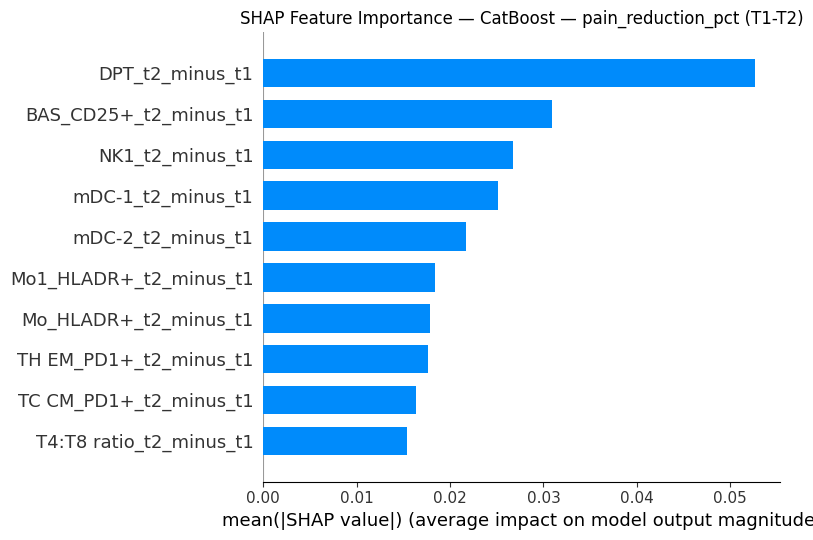

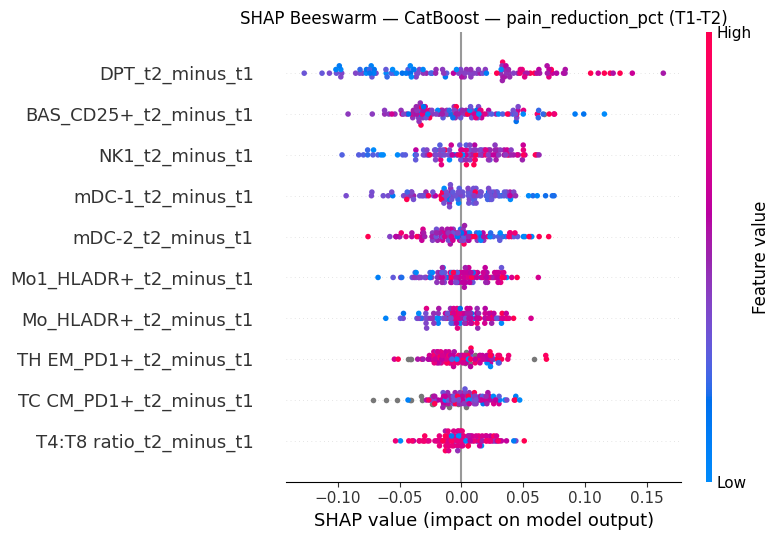

In [ ]:
cb_pct_model = CatBoostRegressor()
cb_pct_model.load_model(os.path.join(MODEL_DIR, 'cb_pct_model.cbm'))
cb_pct_X = joblib.load(os.path.join(MODEL_DIR, 'cb_pct_X.pkl'))

# SHAP plot on saved model
print('\nSHAP — CatBoost (pain_reduction_pct, T1-T2)')
cb_pct_shap = model.plot_shap_regressor(
    cb_pct_model, cb_pct_X, 'CatBoost — pain_reduction_pct (T1-T2)')
